# EDA — Kaggle CBC (vizeno)

**Nguồn**: Kaggle `vizeno/complete-blood-count-cbc-dataset` — người dùng tự tải tay.

**File**: `Data/tabular/kaggle_cbc_vizeno/blood_count_dataset.csv` — 417 dòng × 9 cột: Age, Gender, Hemoglobin, Platelet_Count, White_Blood_Cells, Red_Blood_Cells, MCV, MCH, MCHC.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

plt.rcParams['figure.figsize'] = (10, 5)
DATA = Path(r'D:\AI_08_V1\Data')

df = pd.read_csv(DATA / 'tabular' / 'kaggle_cbc_vizeno' / 'blood_count_dataset.csv')
print('Shape:', df.shape)
print('Missing values:', df.isna().sum().sum())
n_dup = df.duplicated().sum()
print(f'Dòng trùng lặp: {n_dup} ({n_dup/len(df)*100:.1f}%)')
df.describe().round(2)

Shape: (417, 9)
Missing values: 0
Dòng trùng lặp: 323 (77.5%)


,Age,Hemoglobin,Platelet_Count,White_Blood_Cells,Red_Blood_Cells,MCV,MCH,MCHC
count,417.00,417.00,417.00,417.00,417.00,417.00,417.00,417.00
mean,41.80,12.96,305875.30,7577.70,4.87,88.63,29.01,32.41
std,12.12,1.28,59000.19,838.79,0.59,4.71,1.76,0.49
min,22.00,10.20,180000.00,5600.00,3.60,76.00,24.00,32.00
25%,31.00,12.00,260000.00,7100.00,4.40,86.00,28.00,32.00
50%,40.00,13.00,310000.00,7600.00,5.00,89.00,29.00,32.00
75%,50.00,14.00,360000.00,8200.00,5.40,92.00,30.00,33.00
max,70.00,15.20,400000.00,9200.00,5.80,96.00,32.00,33.00


Trước loại trùng: 417 dòng | Sau loại trùng: 94 dòng


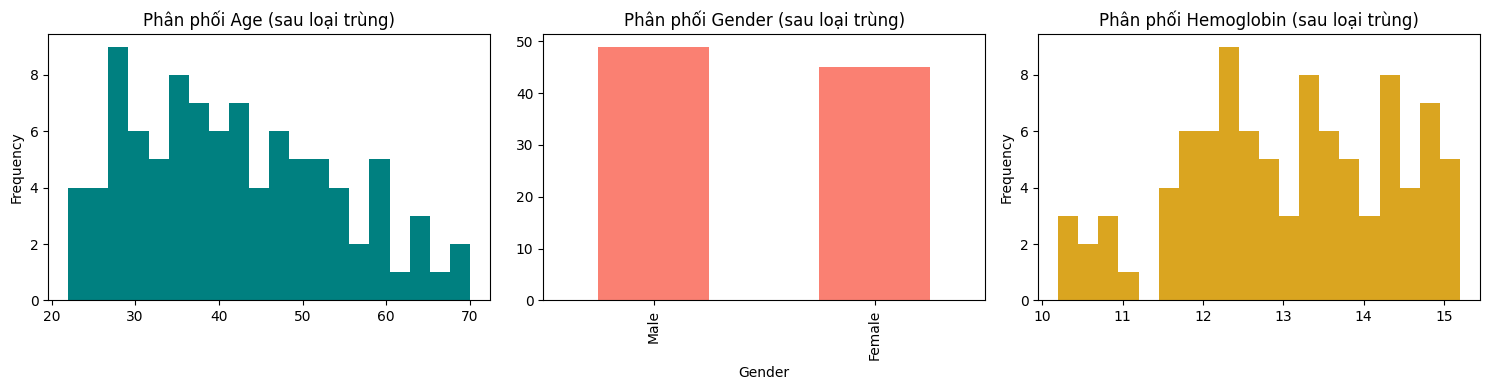

In [2]:
# So sánh dữ liệu gốc vs sau khi loại trùng lặp + phân phối Age/Gender
df_unique = df.drop_duplicates()
print(f'Trước loại trùng: {len(df)} dòng | Sau loại trùng: {len(df_unique)} dòng')

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
df_unique['Age'].plot.hist(ax=axes[0], bins=20, color='teal')
axes[0].set_title('Phân phối Age (sau loại trùng)')
df_unique['Gender'].value_counts().plot.bar(ax=axes[1], color='salmon')
axes[1].set_title('Phân phối Gender (sau loại trùng)')
df_unique['Hemoglobin'].plot.hist(ax=axes[2], bins=20, color='goldenrod')
axes[2].set_title('Phân phối Hemoglobin (sau loại trùng)')
plt.tight_layout()
plt.show()

## Nhận xét

- Không có missing value.
- **Trùng lặp cực nặng: 323/417 dòng (77.5%)** — mức trùng lặp cao nhất trong toàn bộ kho, chỉ còn ~94 dòng thật sự khác nhau.
- Không có cột nhãn bệnh, nhưng có Age + Gender — bù được phần nhỏ cho nhóm "thông tin bệnh nhân".
- Giá trị các chỉ số nằm trong khoảng sinh học hợp lý (không có giá trị âm/vô lý như bộ CBC Test dataset #1).